# Principal Component Analysis-Unsupervised

Principal Component Analysis (PCA) is a widely used dimensionality reduction technique in machine learning and statistics. By **relying on the correlation between variables** in the dataset, PCA reduces the original dataset to a smaller number of components. These components aim to capture the "main characteristics" of the original dataset while preserving the maximum variance.

- This method is used to identify the components that best summarize the variability in multi-dimensional datasets.

- 20 kg of pomegranates vs. drinking 2 liters of pomegranate juice?

- Disadvantages of working with too many features... for example, challenges in visualization and interpreting the visuals.

- Solves the issue of multicollinearity.

- It performs well when there are linear relationships between features.

**Steps to Apply PCA:**

1. **Standardize the Data:** Since features may have different scales (e.g., engine power in "hp" and weight in "kg"), you should standardize the data.

2. **Calculate the Covariance Matrix:** This determines the relationships between features.

3. **Compute Eigenvalues and Eigenvectors:** These are obtained from the covariance matrix, representing the magnitude and direction of the variance, respectively.

4. **Select Principal Components:** Rank the principal components by their eigenvalues and choose the first 2 or 3 principal components.

5. **Transform the Data to New Components:** Convert the original data into a new dataset using the selected principal components.

**NOTE**: If, at the end of the process, we need to discuss each feature individually with the customer or the relevant company (e.g., explaining how one feature impacts the outcome and how another feature affects it), then applying PCA may not be appropriate. However, if the final goal is a general evaluation, PCA could be suitable. 

For instance, if we are aiming to interpret the outcome of a signal flow in a readable and evaluable format based on the signal flows, PCA might be applicable. Let’s say there are 10 signal channels, and the focus is not on what each channel conveys but on the final result. In that case, PCA could be used because the final outcome is what matters here.

## Imports

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
plt.rcParams["figure.figsize"] = (10,6)
import warnings
warnings.filterwarnings('ignore')

Example applications of PCA:

- **Noisy Data:** PCA can help reduce noise or insignificant variations in the dataset, as the principal components focus on larger variances, and components with low variance are often considered noise.
  **Here, the ultimate clarity of the signals is important; the sources are not significant, meaning the features are irrelevant in this context.**

- **E-commerce Sales Data:** We can reduce dozens of features to 2 components to explain customer behavior and their tendency to purchase products.

In [2]:
from sklearn.datasets import load_breast_cancer    # loading the breast cancer dataset of sklearn library
cancer = load_breast_cancer()
print(cancer.DESCR)   # 30 feature, 569 rows, features related to the tumor, 

# a dataset containg the information whether a person does or doesn't have cancer

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [3]:
X=pd.DataFrame(cancer.data,columns=cancer.feature_names)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X.shape   # 30 feature 

(569, 30)

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
# Let's count the benign(non-cancerous)-malignant(cancerous) (i.e., 0-1) values as the target variable
pd.DataFrame(cancer.target).value_counts()   

1    357
0    212
Name: count, dtype: int64

In [8]:
# We swapped 0-1 because we are focusing on the cancerous data class, let's set it to 1.
y = pd.Series(cancer.target).map({0:1, 1:0})  
y.head()

0    1
1    1
2    1
3    1
4    1
dtype: int64

In [9]:
# selected the 1 as target variable 212 cancer cases
y.value_counts()

0    357
1    212
Name: count, dtype: int64

In [10]:
a = pd.concat([X,y], axis=1)  # added the y at last
a

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,0
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [11]:
a.groupby(0).mean()  # getting the average of 0 and 1 classes with groupby

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,0.284082,1.220380,2.000321,21.135148,0.007196,0.021438,0.025997,0.009858,0.020584,0.003636,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
1,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,0.609083,1.210915,4.323929,72.672406,0.006780,0.032281,0.041824,0.015060,0.020472,0.004062,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


In [12]:
pd.set_option('display.max_rows', 500) 

## PCA with sklearn

## Scaling Data

In PCA, scaling is absolutely essential and non-negotiable.

PCA aims to maximize the variance of features in the dataset, meaning that features with different scales can significantly affect the results. For example, if one feature has much larger values than others, it may dominate the PCA results, causing the variance of other features to be overlooked.

Scaling the features when applying PCA is a crucial step for achieving more balanced and accurate results.

As for methods, both approaches can be tried, but since the goal of PCA is to capture the variance, StandardScaler is commonly used. Standardization works by preserving the original variance among features.

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
# scaling operation

scaled_X = scaler.fit_transform(X)

**IMPORTANT and GENERAL NOTE:**

PCA first creates a covariance matrix, then generates eigenvalues, and from there, forms new components. 
Why the covariance matrix? Because it identifies relationships among features with linear correlations in the background and uses them to create new components. In the heatmap below, we see that some features have a high correlation with each other.

**When performing PCA, all features have an effect on each component.** We know that they are more concentrated in the first component, slightly less in the second, and even less in the subsequent ones.

**In summary, PCA creates components based on the linear relationships between features in the background**, and it derives this linear relationship from the correlation matrix.

<Axes: >

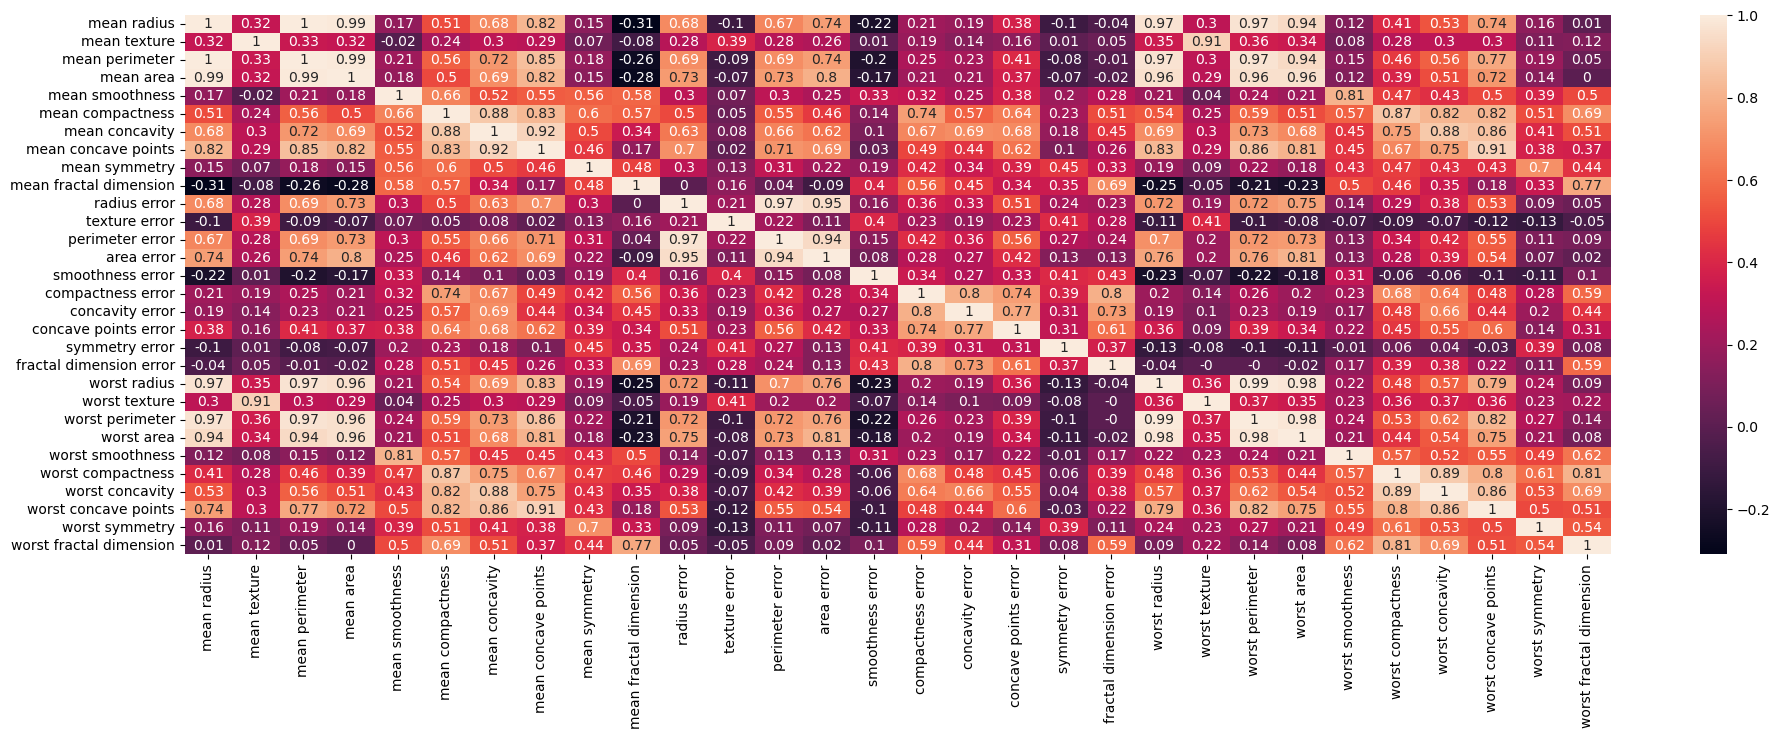

In [29]:
# adding it to a df and visualizing heatmap

df_scaled_X = pd.DataFrame(scaled_X, columns = X.columns)
plt.figure(figsize = (23, 7))
sns.heatmap(df_scaled_X.corr().round(2), annot = True)

There are features in the heatmap with high correlation to each other. PCA will address this exactly. PCA works well in cases of strong features or linear relationships.

## PCA

In [16]:
from sklearn.decomposition import PCA

Here, we will enter the `n_components` value.

When selecting the number of components (`n_components`) in PCA, there are several important factors to consider:

- **Explained Variance Ratio**: When determining the number of components, you should decide how much of the total variance in your dataset you want to retain. Each component explains a portion of the total variance in the dataset. Typically, you select the number of components that will explain a large percentage of the total variance (e.g., 70-80%).

- **Model Performance**: You can select `n_components` to optimize the performance of the machine learning model where PCA is applied. By experimenting with different numbers of components, you can compare the accuracy or other performance metrics of the model.

- **Visualization**: If you are using PCA to visualize your data, usually two or three components will be sufficient, as this allows you to easily visualize the data in two or three dimensions.

- **Computational Cost**: Using fewer components typically means lower computational cost. When working with large datasets, this can be an important factor.

In [17]:
pca = PCA(n_components=2)   # selected two components

In [18]:
principal_components = pca.fit_transform(scaled_X)   # converted 30 features to 2 components

In [19]:
principal_components

# converted 30 features to 2 components as 2 columns

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [20]:
component_df = pd.DataFrame(data = principal_components, columns = ["first_component", 
                                                                    "second_component"])
component_df

# check the effect of components - converted to dataframe

,first_component,second_component
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072
...,...,...
564,6.439315,-3.576817
565,3.793382,-3.584048
566,1.256179,-1.902297
567,10.374794,1.672010


In PCA, the weights of the features within a component are called "loadings." These loadings indicate how much the component is represented by that feature.

If the loading for a feature in one component is positive and in another component is negative, it shows that these features affect the two components in opposite directions.

For example, for a feature:

- A loading value of 0.21 in the first component means that this feature positively contributes to the variance captured by this component. In other words, as the value of this component increases, the feature also increases.
- A loading value of -0.19 in the second component means that this feature negatively contributes to the variance captured by this component. This means that as the value of the component increases, the feature decreases.

**Data Interpretation:** Since the components after PCA are linear combinations of the original features, interpreting these components directly can often be difficult. However, the loadings (weights) of the features in the components help indicate which features are more important for a particular component.

## Eigenvalues & Eigenvectors

There are two key concepts behind PCA: Eigenvalues (EV) and Eigenvectors (EVec).



In [21]:
#Eigenvectors. (eigenvectors for each components)

pca.components_

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]])

By multiplying the values here with the features, we calculate the contributions they make. In other words, when we multiply these values by scaled_X, we obtain the first and second components. The contributions here can be evaluated as variance. When making these contributions, since the data starts with 100% in the first contribution, it contributes about 40% to the first component, about 25% to the second component, and if there were a third component, it would contribute about 10%.

This transfer of information is determined by the eigenvectors.

Now, let's take a look at this in DataFrame form

In [22]:
eigenvectors_first_component = pca.components_[0]  # In the first component, all features represent the direction of maximum variance..
eigenvectors_first_component

array([0.21890244, 0.10372458, 0.22753729, 0.22099499, 0.14258969,
       0.23928535, 0.25840048, 0.26085376, 0.13816696, 0.06436335,
       0.20597878, 0.01742803, 0.21132592, 0.20286964, 0.01453145,
       0.17039345, 0.15358979, 0.1834174 , 0.04249842, 0.10256832,
       0.22799663, 0.10446933, 0.23663968, 0.22487053, 0.12795256,
       0.21009588, 0.22876753, 0.25088597, 0.12290456, 0.13178394])

In [23]:
# check the effect of each feature on first component

first_eigenvectors = pd.DataFrame(eigenvectors_first_component, index=X.columns, 
                                  columns=["first_eigenvectors"]).sort_values("first_eigenvectors", ascending=False)

first_eigenvectors

,first_eigenvectors
mean concave points,0.260854
mean concavity,0.258400
worst concave points,0.250886
mean compactness,0.239285
worst perimeter,0.236640
worst concavity,0.228768
worst radius,0.227997
mean perimeter,0.227537
worst area,0.224871
mean area,0.220995


In [24]:
# same steps for 2nd component

eigenvectors_second_component = pca.components_[1]
eigenvectors_second_component

array([-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
        0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
       -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
        0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
       -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
        0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947])

In [25]:
# check the effect of each feature on second component

second_eigenvectors = pd.DataFrame(eigenvectors_second_component, index=X.columns, 
                                   columns=["second_eigenvectors"]).sort_values("second_eigenvectors", ascending=False)

second_eigenvectors

,second_eigenvectors
mean fractal dimension,0.366575
fractal dimension error,0.280092
worst fractal dimension,0.275339
compactness error,0.232716
smoothness error,0.204430
concavity error,0.197207
mean symmetry,0.190349
mean smoothness,0.186113
symmetry error,0.183848
worst smoothness,0.172304


In [26]:
# bringing the effects in one table

pd.concat([first_eigenvectors, second_eigenvectors], axis=1)


,first_eigenvectors,second_eigenvectors
mean concave points,0.260854,-0.034768
mean concavity,0.258400,0.060165
worst concave points,0.250886,-0.008257
mean compactness,0.239285,0.151892
worst perimeter,0.236640,-0.199878
worst concavity,0.228768,0.097964
worst radius,0.227997,-0.219866
mean perimeter,0.227537,-0.215181
worst area,0.224871,-0.219352
mean area,0.220995,-0.231077


In [27]:
# Now, let's verify the values obtained at line 21.

In [30]:
df_scaled_X.loc[0]

mean radius                1.097064
mean texture              -2.073335
mean perimeter             1.269934
mean area                  0.984375
mean smoothness            1.568466
mean compactness           3.283515
mean concavity             2.652874
mean concave points        2.532475
mean symmetry              2.217515
mean fractal dimension     2.255747
radius error               2.489734
texture error             -0.565265
perimeter error            2.833031
area error                 2.487578
smoothness error          -0.214002
compactness error          1.316862
concavity error            0.724026
concave points error       0.660820
symmetry error             1.148757
fractal dimension error    0.907083
worst radius               1.886690
worst texture             -1.359293
worst perimeter            2.303601
worst area                 2.001237
worst smoothness           1.307686
worst compactness          2.616665
worst concavity            2.109526
worst concave points       2

In [31]:
# We multiplied the values above by the vector and took the sum
# The result should match the value from line 21

(df_scaled_X.loc[0] * eigenvectors_first_component).sum()

9.192836826213238

In [32]:
# Verification of the 2nd component in the same row as the value above
(df_scaled_X.loc[0] * eigenvectors_second_component).sum()

1.948583070782124

In [33]:
# The first table containing the values above

component_df.head()

,first_component,second_component
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


In [34]:
# Let's check the explained variance and the contributions to the 1st and 2nd components.
pca.explained_variance_ #Eigenvalues

array([13.30499079,  5.7013746 ])

## Corr between components

We mentioned that there is no correlation between the components, and here is the proof of that. You can see that there is no relationship between the first component and the second component.

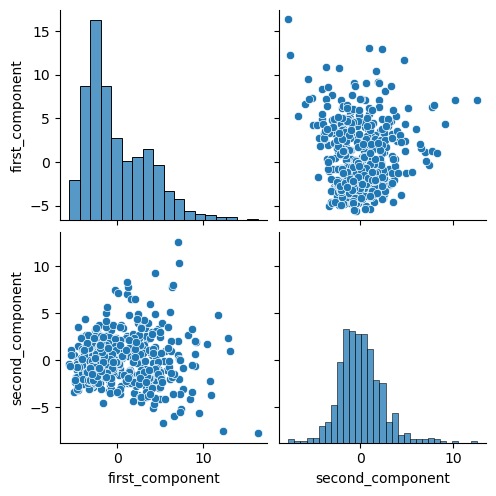

In [35]:
sns.pairplot(component_df)

In [36]:
component_df.corr().round()

# Due to the nature of PCA, these two components are orthogonal to each other, meaning their correlation is 0.

,first_component,second_component
first_component,1.0,-0.0
second_component,-0.0,1.0


## Finding optimal number of components

If the dataset carries 100% of the information, the explained variance ratio shows how much of this 100% is explained by the components. To check how much variance the two components hold from the total variance of the data, I wrote the following code:

The result shows that 44% of the variance is explained by the first component, and 18% by the second component, meaning that we explain a total of 63% of the variance with these two components.

In [37]:
pca.explained_variance_ratio_    

array([0.44272026, 0.18971182])

In [38]:
pca.explained_variance_ratio_.cumsum()   # cummulative rate 2nd value - the sum of both

array([0.44272026, 0.63243208])

Let's write the code below to decide on the best number of components, similar to the elbow method. We will see the contribution of all components to the variance from 1 to 30. For example, when there are 5 components, it reaches 0.90.

Here, let's take the explained variance (vector) as how much information is gathered in each component and the cumulative variance of each piece of information.

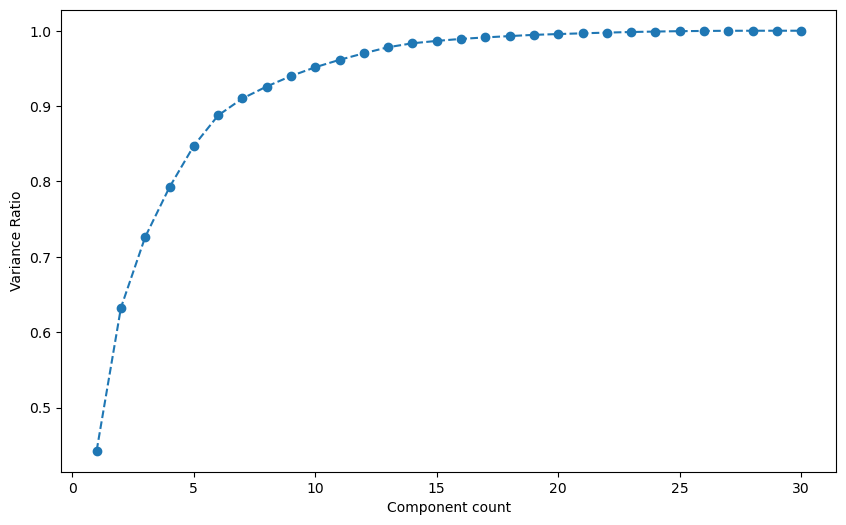

In [39]:
# Let's see how the variance ratio changes cumulatively as each component is added.

pca = PCA().fit(scaled_X)
x = range(1 , 31)
plt.plot(x, np.cumsum(pca.explained_variance_ratio_),"--o")
plt.xlabel("Component count")
plt.ylabel("Variance Ratio");

In [40]:
pca = PCA(n_components=30).fit(scaled_X)   # created 30 component

In [41]:
my_dict = {"explained_variance":pca.explained_variance_, 
        "explained_variance_ratio":pca.explained_variance_ratio_,
        "cumsum_explained_variance_ratio":pca.explained_variance_ratio_.cumsum()}

# created dict to see the values in table

On the far right of the table below, the cumulative explained variance is shown. By the time we reach 30 components, it becomes 1, meaning 100% of the variance is explained.

**NOTE:**  
**Let's present a different perspective:**
Since more concentrated information is present, 2 or 3 components could be selected. As seen from the table, there is no significant contribution after 3 components. It might be best to choose 2. It’s worth experimenting—if the results are good with 2, you can stop at 2, and if 3 works better, you can stop at 3.

In [42]:
df_ev = pd.DataFrame(my_dict, index = range(1,31))
df_ev

,explained_variance,explained_variance_ratio,cumsum_explained_variance_ratio
1,13.304991,0.442720,0.442720
2,5.701375,0.189712,0.632432
3,2.822910,0.093932,0.726364
4,1.984128,0.066021,0.792385
5,1.651633,0.054958,0.847343
6,1.209482,0.040245,0.887588
7,0.676409,0.022507,0.910095
8,0.477456,0.015887,0.925983
9,0.417629,0.013896,0.939879
10,0.351311,0.011690,0.951569


<Axes: ylabel='explained_variance_ratio'>

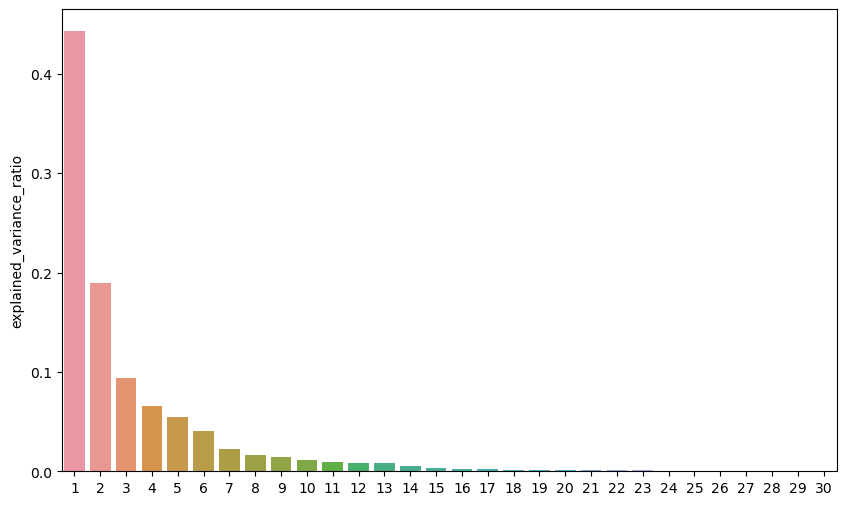

In [43]:
# let's see the values above in a graphic/visual

sns.barplot(x = df_ev.index, y= df_ev.explained_variance_ratio)

In [44]:
# continued with 2 components to get a detailed information. 
pca = PCA(n_components=2)

In [45]:
# repeating the steps above 

principal_components = pca.fit_transform(scaled_X)
principal_components

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [46]:
# see them together in a table
component_df = pd.DataFrame(data = principal_components, columns = ["first_component", 
                                                                    "second_component"])
component_df

,first_component,second_component
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072
...,...,...
564,6.439315,-3.576817
565,3.793382,-3.584048
566,1.256179,-1.902297
567,10.374794,1.672010


## Interpreting PCA results

We’ve reached the interpretation part.

If we are asked to interpret each feature individually at the end, applying PCA would not be the right choice. Without PCA, we can directly say which feature impacts cancer. However, with PCA, we can indicate which features are influential in each component.

We'll do this through correlation.

For this, I'm taking my scaled data.

In [47]:
scaled_df = pd.DataFrame(scaled_X, columns=X.columns)
scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [48]:
# using the relevant data

combined_df = pd.concat([component_df, scaled_df], axis =1)
correlation = combined_df.corr()
correlation.head()

,first_component,second_component,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
first_component,1.000000e+00,8.940960e-17,0.797767,0.378013,0.829236,0.805393,0.519653,0.872050,0.941713,0.950654,0.503535,0.234565,0.750668,0.063515,0.770155,0.739337,0.052958,0.620981,0.559742,0.668445,0.154881,0.373799,0.830910,0.380727,0.862408,0.819517,0.466310,0.765672,0.833719,0.914327,0.447913,0.480273
second_component,8.940960e-17,1.000000e+00,-0.557903,-0.142438,-0.513349,-0.551270,0.444002,0.362361,0.143534,-0.082943,0.454107,0.874523,-0.251811,0.214661,-0.213414,-0.363318,0.487701,0.555180,0.470469,0.310902,0.438598,0.668203,-0.524526,-0.108469,-0.476841,-0.523298,0.411059,0.342564,0.233709,-0.019699,0.338485,0.656865
mean radius,7.977668e-01,-5.579027e-01,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,3.780132e-01,-1.424382e-01,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,8.292355e-01,-5.133487e-01,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019


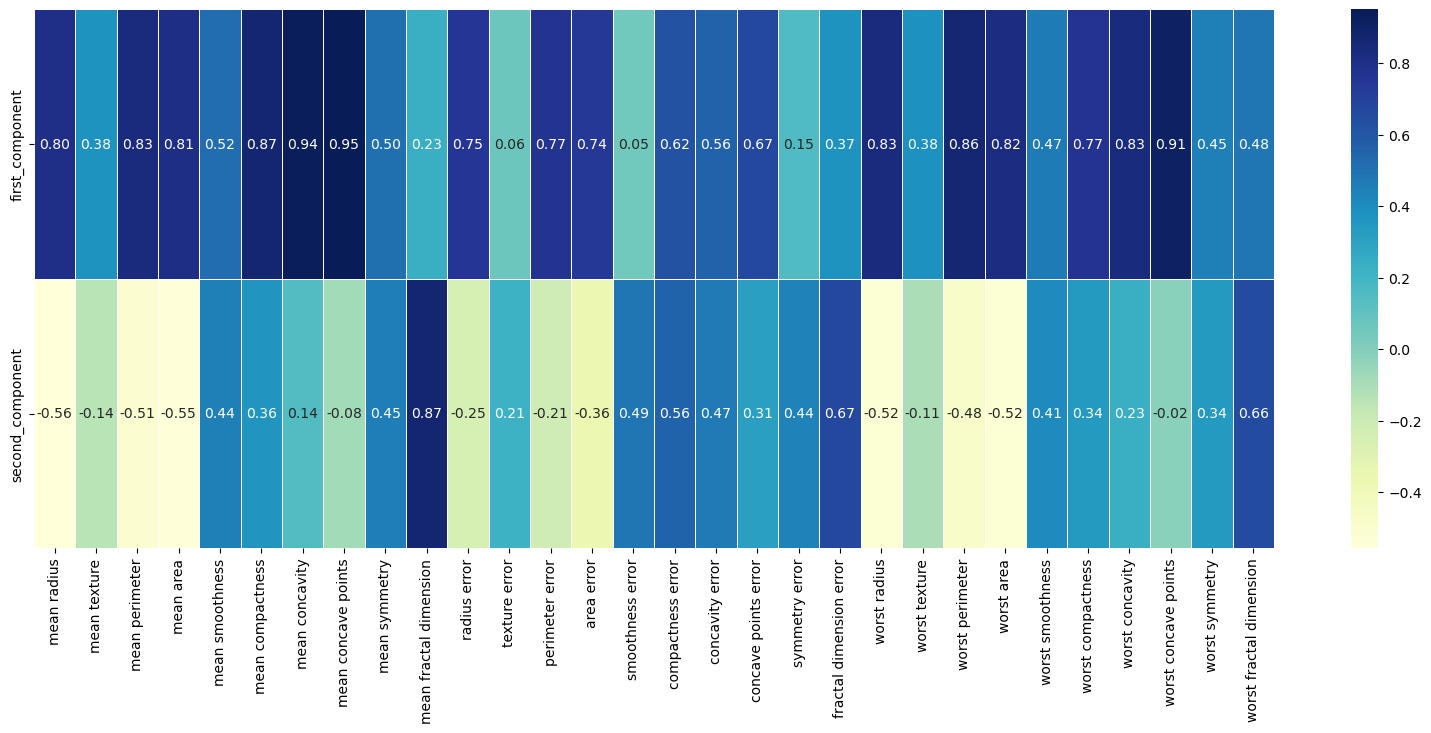

In [47]:
# Let's check the correlation between them
# In the code below, for the heatmap, we are selecting only the first_component and second_component along with the 
# columns starting from mean_radius onwards on the right side. 

fig, ax = plt.subplots(figsize=(20, 7))
sns.heatmap(correlation.iloc[:2,2:], cmap='YlGnBu', linewidths=.7, annot=True, fmt='.2f')
plt.show()

When I check the correlation between these features, I will first look at the ones with values above 0.60.

In the table above, the first values to check are those over 0.6. The dark colors indicate high values. Some of the features to the left of the dark-colored cells in the top row have high values. Below, we’ve listed these features.

My comment is as follows: In the first component, those with dark blue values like 0.80-0.90 **tend to increase together**. This means if the mean radius increases, the mean concavity will also increase. If there is an increase in one, I expect an increase in the others as well. These are important for cancer diagnosis. The features I need to pay attention to have merged in the first component. There are high correlations in that component, and all highly correlated features are important for cancer diagnosis. With PCA, we are making overall evaluations.

<Axes: xlabel='first_component', ylabel='second_component'>

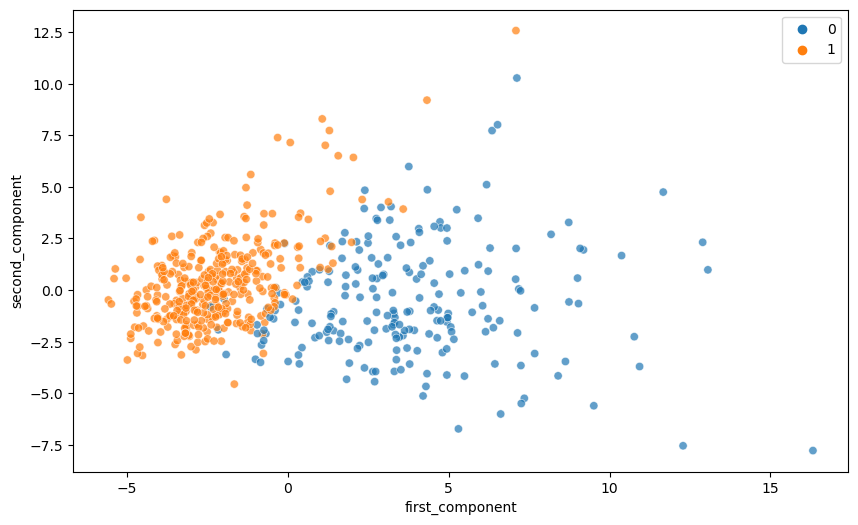

In [48]:
sns.scatterplot(x = component_df.first_component, y= component_df.second_component, hue=cancer.target, alpha=0.7)

Here, I provided my first and second components and visualized the results by giving the actual values to hue. The first and second components are nicely separated from each other, meaning a good distinction has been made based on these two components.

If we were dealing with 3-4 components, our interpretation would shift from a simple 0-1 (cancer or not) evaluation to a more nuanced assessment, such as considering stages like 3rd stage or 4th stage of cancer.

## K-Means Algorithm Application

Let's make an evaluation using KMeans here.

First, let's check the inertia value for the 2 components. A lower inertia value is considered better. It indicates the compactness of the clusters around their centroids.

### Hopkins test

In [49]:
from sklearn.neighbors import BallTree
import numpy as np
import pandas as pd
def hopkins(data_frame, sampling_size):
    """Assess the clusterability of a dataset. A score between 0 and 1, a score around 0.5 express
    no clusterability and a score tending to 0 express a high cluster tendency.
    Parameters
    ----------
    data_frame : numpy array
        The input dataset
    sampling_size : int
        The sampling size which is used to evaluate the number of DataFrame.
    Returns
    ---------------------
    score : float
        The hopkins score of the dataset (between 0 and 1)
    Examples
    --------
    >>> from sklearn import datasets
    >>> from pyclustertend import hopkins
    >>> X = datasets.load_iris().data
    >>> hopkins(X,150)
    0.16
    """
    if type(data_frame) == np.ndarray:
        data_frame = pd.DataFrame(data_frame)
    # Sample n observations from D : P
    if sampling_size > data_frame.shape[0]:
        raise Exception(
            'The number of sample of sample is bigger than the shape of D')
    data_frame_sample = data_frame.sample(n=sampling_size)
    # Get the distance to their neirest neighbors in D : X
    tree = BallTree(data_frame, leaf_size=2)
    dist, _ = tree.query(data_frame_sample, k=2)
    data_frame_sample_distances_to_nearest_neighbours = dist[:, 1]
    # Randomly simulate n points with the same variation as in D : Q.
    max_data_frame = data_frame.max()
    min_data_frame = data_frame.min()
    uniformly_selected_values_0 = np.random.uniform(min_data_frame[0], max_data_frame[0], sampling_size)
    uniformly_selected_values_1 = np.random.uniform(min_data_frame[1], max_data_frame[1], sampling_size)
    uniformly_selected_observations = np.column_stack((uniformly_selected_values_0, uniformly_selected_values_1))
    if len(max_data_frame) >= 2:
        for i in range(2, len(max_data_frame)):
            uniformly_selected_values_i = np.random.uniform(min_data_frame[i], max_data_frame[i], sampling_size)
            to_stack = (uniformly_selected_observations, uniformly_selected_values_i)
            uniformly_selected_observations = np.column_stack(to_stack)
    uniformly_selected_observations_df = pd.DataFrame(uniformly_selected_observations)
    # Get the distance to their neirest neighbors in D : Y
    tree = BallTree(data_frame, leaf_size=2)
    dist, _ = tree.query(uniformly_selected_observations_df, k=1)
    uniformly_df_distances_to_nearest_neighbours = dist
    # return the hopkins score
    x = sum(data_frame_sample_distances_to_nearest_neighbours)
    y = sum(uniformly_df_distances_to_nearest_neighbours)
    if x + y == 0:
        raise Exception('The denominator of the hopkins statistics is null')
    return x / (x + y)[0]

In [50]:
hopkins(component_df, component_df.shape[0]) # suitable for clusters if test results are closer to 0 

0.1399606933537474

In [51]:
# inertia

from sklearn.cluster import KMeans

ssd = []

K = range(2,10)

for k in K:
    model = KMeans(n_clusters =k, random_state=42)
    model.fit(component_df)
    ssd.append(model.inertia_)

Text(0.5, 1.0, 'elbow method')

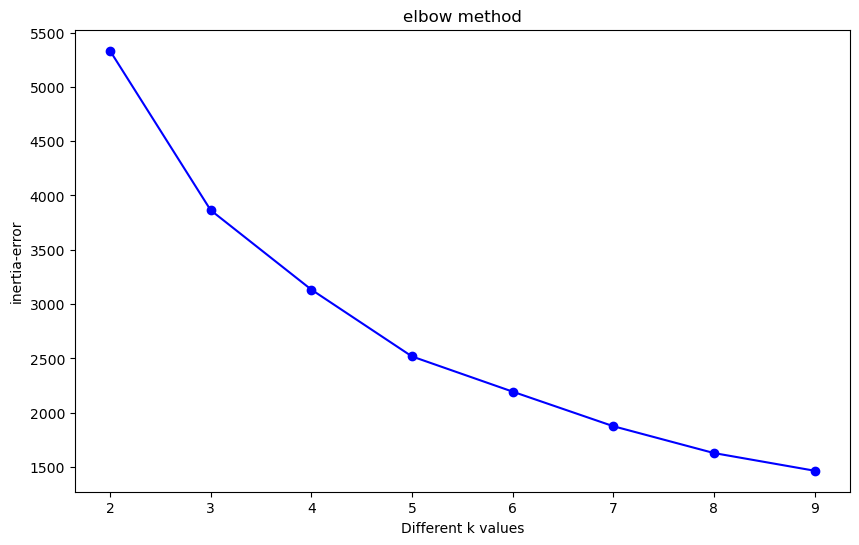

In [52]:
plt.plot(K, ssd, "bo-")
plt.xlabel("Different k values")
plt.ylabel("inertia-error") 
plt.title("elbow method")

# looking for a sharp drop in the following visual
# repeating the steps 

In [53]:
ssd

[5332.555574203629,
 3864.5452840272073,
 3133.6178606934754,
 2518.1650119970454,
 2194.0807807340384,
 1875.926237076573,
 1628.6595343244292,
 1465.9534175574026]

In [54]:
pd.Series(ssd).diff()

0            NaN
1   -1468.010290
2    -730.927423
3    -615.452849
4    -324.084231
5    -318.154544
6    -247.266703
7    -162.706117
dtype: float64

In [55]:
df_diff =pd.DataFrame(-pd.Series(ssd).diff()).rename(index = lambda x : x+1)
df_diff

,0
1,NaN
2,1468.010290
3,730.927423
4,615.452849
5,324.084231
6,318.154544
7,247.266703
8,162.706117


<Axes: >

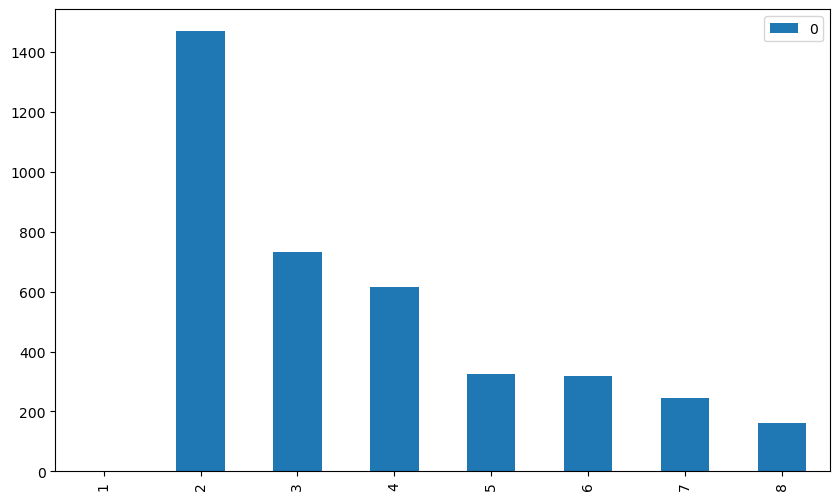

In [58]:
df_diff.plot(kind='bar')  
# there is a sharper drop in 3

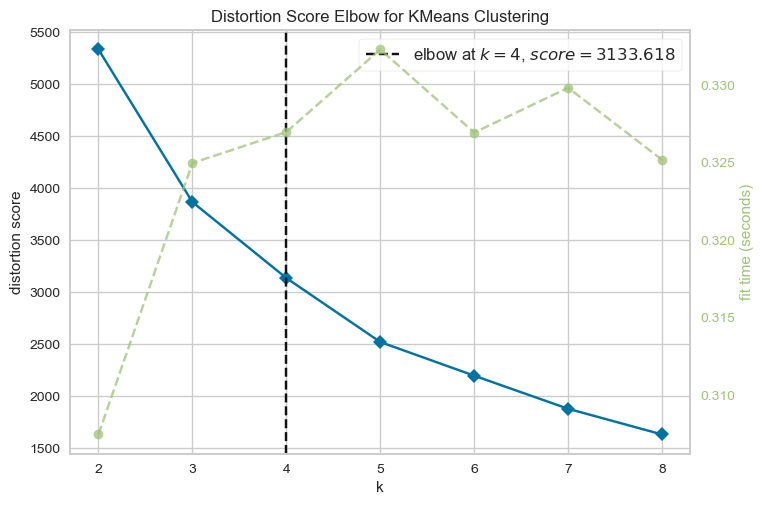

In [56]:
from yellowbrick.cluster import KElbowVisualizer

model_ = KMeans(random_state=42)
visualizer = KElbowVisualizer(model_, k=(2,9))

visualizer.fit(component_df)        # Fit the data to the visualizer
visualizer.show();

yellowbrikck said 4,let's look at silhouette

In [57]:
from sklearn.metrics import silhouette_score

range_n_clusters = range(2,9)
for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(component_df)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(component_df, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

For n_clusters=2, the silhouette score is 0.5084690190658254
For n_clusters=3, the silhouette score is 0.47667244606986847
For n_clusters=4, the silhouette score is 0.4656018483069523
For n_clusters=5, the silhouette score is 0.36344947291960206
For n_clusters=6, the silhouette score is 0.35720646057460126
For n_clusters=7, the silhouette score is 0.3661212405011196
For n_clusters=8, the silhouette score is 0.37263972521777144


For silhouette, all except 2 are close to each other. 2-3-4 can be selected. With `n_cluster=2` in this data, clustering can be done as cancer or not cancer, or a ranking based on cancer stages can be made if 3 or 4 components are chosen. Perhaps it might be appropriate to classify the cluster according to cancer stages. If classification as cancer or not cancer is desired, continue with 2 components.

<Axes: xlabel='first_component', ylabel='second_component'>

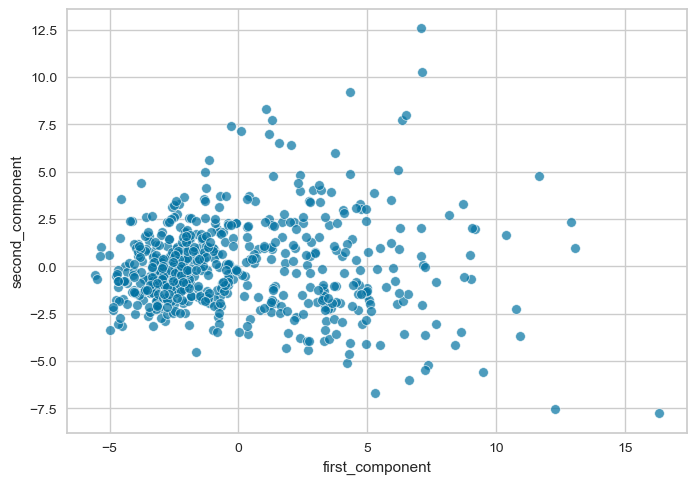

In [58]:
sns.scatterplot(x = component_df.first_component, y= component_df.second_component, alpha=0.7)

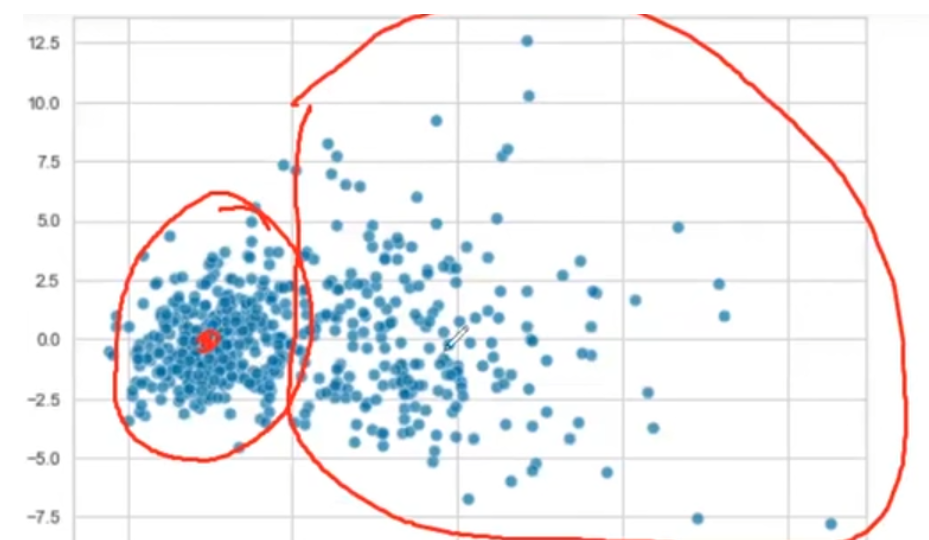

The two components can be evaluated as shown in the image above. Alternatively, the right side can also be divided into two parts, resulting in 3 clusters.

**NOTE**: The customer instructed to proceed as cancer or not cancer.

We will set the number of clusters to 2 and proceed.

In [59]:
model = KMeans(n_clusters =2, random_state=42)
clusters = model.fit_predict(component_df)
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [60]:
ct = pd.crosstab(y, clusters)
ct

# 53 errors can be seen overall

col_0,0,1
row_0,,
0,341,16
1,37,175


comparing the actual values with cluster predictions

Text(0.5, 1.0, 'K_means')

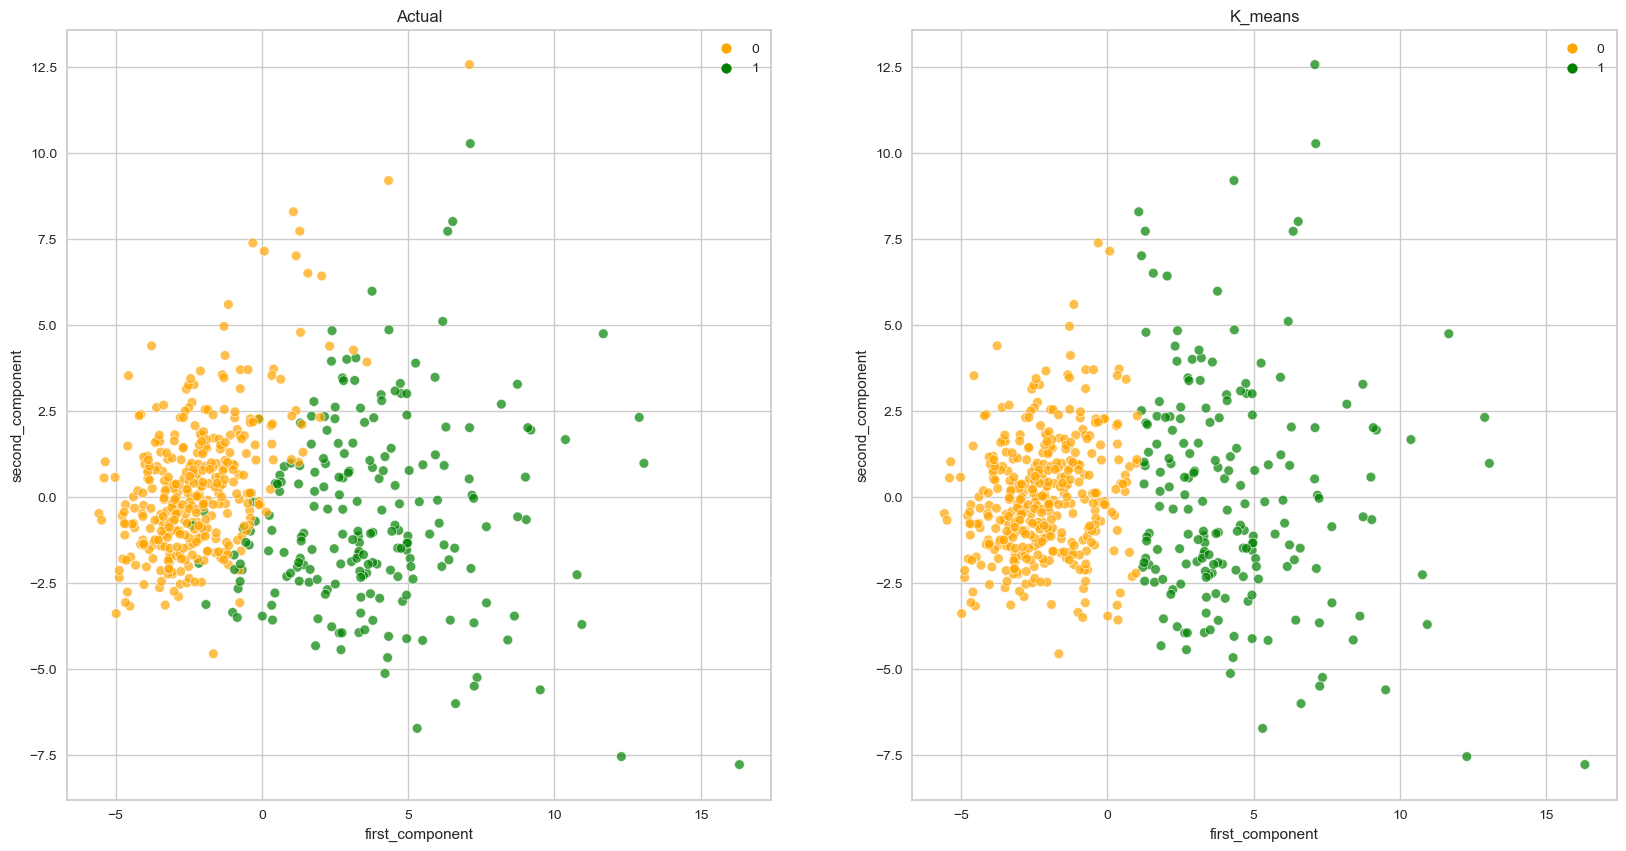

In [61]:
plt.figure(figsize = (20,10))

plt.subplot(121)
sns.scatterplot(x = component_df.first_component, y= component_df.second_component, hue=y, alpha=0.7,
                palette=['orange','green'])
plt.title("Actual")

plt.subplot(122)
sns.scatterplot(x = component_df.first_component, y= component_df.second_component, hue=clusters, alpha=0.7,
               palette=['orange','green'])
plt.title("K_means")

In this graph, we made a prediction very close to the reality. We concentrated the data with PCA and then performed clustering with KMeans.